# eGenes plotting 
- all genes - snp+indel - CC/SN combined
- panel A and B

In [ ]:
import pandas as pd
import torch
import tensorqtl
from tensorqtl import pgen, cis, trans, post

import io
import sys
import post 
import glob
import re

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

from statsmodels.stats.multitest import multipletests
import statsmodels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} (CUDA {torch.version.cuda}), device: {device}")
print(f"pandas: {pd.__version__}")
print(f"tensorqtl: {tensorqtl.__version__}")


matplotlib.rcParams['pdf.fonttype'] = 42

During startup - Warning messages:
1: Setting LC_TIME failed, using "C" 
2: Setting LC_MESSAGES failed, using "C" 
3: Setting LC_MONETARY failed, using "C" 
4: Setting LC_PAPER failed, using "C" 
5: Setting LC_MEASUREMENT failed, using "C" 


torch: 2.6.0+cu124 (CUDA 12.4), device: cpu
pandas: 2.2.3
tensorqtl: 1.0.10


In [2]:
# cell type name correction
cell_type_labels_corr={"L2_3_IT": "L2/3 IT","L5_IT": "L5 IT", "L6_CT": "L6 CT", "L4_IT": "L4 IT", "L5_IT_A": "L5 IT A", "L5_IT_B": "L5 IT B", "L6_IT": "L6 IT", "L6_IT_Car3": "L6 IT Car3", "L5_6_NP": "L5/6 NP", "neurons" : "Neurons"}


In [ ]:
def calculate_and_extract_qvalues(cis_df, fdr=0.05, qvalue_lambda=0.85):
    output_buffer = io.StringIO()
    sys.stdout = output_buffer
    post.calculate_qvalues(cis_df, fdr=fdr, qvalue_lambda=qvalue_lambda)
    sys.stdout = sys.__stdout__
    output = output_buffer.getvalue()

    # Print the captured output for debugging
    print("Captured Output:")
    print(output)

    # Extract the min p-value threshold for the given FDR
    fdr_str = f"{fdr:.2f}"
   
    min_p_value_threshold_match = re.search(rf'min p-value threshold @ FDR {fdr_str}:\s*([\d\.e-]+)', output)
    if min_p_value_threshold_match:
        min_p_value_threshold = float(min_p_value_threshold_match.group(1))
    else:
        min_p_value_threshold = float('nan') 
    print(f"Extracted min p-value threshold @ FDR {fdr}: {min_p_value_threshold}")
    column_name = f'min_p-value_threshold_at_FDR_{fdr}'
    cis_df[column_name] = min_p_value_threshold

    return cis_df

In [4]:
def process_directory(path, directory, prefix_list, fdr):

    cis_dfs = []  # To store cis DataFrames


    for prefix in prefix_list:
        prefix_res = f'eQTL_{prefix}'
        cis_df = pd.read_csv(f'{path}/results/{directory}/{prefix_res}.csv.gz', index_col=0)  # output from map_cis
        cell_type = prefix.split('_')[2:]
        cell_type = "_".join(cell_type)
        cis_df = calculate_and_extract_qvalues(cis_df, fdr=fdr)
        cis_df = cis_df[cis_df['qval'] <= fdr]
        cis_df["cell_type"] = cell_type
        cis_df["variant_type"] = directory
        cis_dfs.append(cis_df)


    return cis_dfs 

In [ ]:
def process_all_directories(path, directories, prefix_list, fdr):
    all_egenes = pd.DataFrame()
    all_cis_dfs = []


    for directory in directories:
        cis_dfs = process_directory(path, directory, prefix_list, fdr)
        all_cis_dfs.extend(cis_dfs)
     
    combined_cis_df = pd.concat(all_cis_dfs, ignore_index=False)
  
    return combined_cis_df 

## Substantia nigra eGenes

In [ ]:
directories = ['snp', 'indel']

date= 'XXXXX' # change as appropriate

prefix_list = prefix_list = [f'{date}_sn_Astro',
    f'{date}_sn_Micro-PVM',
    f'{date}_sn_OPC',
    f'{date}_sn_Oligo',
    f'{date}_sn_neurons',]

fdr = 0.05
path = '../../snRNA/01_analysis/04_QTL/sn/'
# Process all directories
combined_cis_df_sn = process_all_directories(path, directories, prefix_list, fdr)



Captured Output:
Computing q-values
  * Number of phenotypes tested: 18114
  * Correlation between Beta-approximated and empirical p-values: nan
  * Calculating q-values with lambda = 0.850
  * Proportion of significant phenotypes (1-pi0): 0.00
  * QTL phenotypes @ FDR 0.05: 116
  * min p-value threshold @ FDR 0.05: 0.000322394

Extracted min p-value threshold @ FDR 0.05: 0.000322394
Captured Output:
Computing q-values
  * Number of phenotypes tested: 17888
  * Correlation between Beta-approximated and empirical p-values: nan
  * Calculating q-values with lambda = 0.850
  * Proportion of significant phenotypes (1-pi0): 0.14
  * QTL phenotypes @ FDR 0.05: 180
  * min p-value threshold @ FDR 0.05: 0.000601806

Extracted min p-value threshold @ FDR 0.05: 0.000601806
Captured Output:
Computing q-values
  * Number of phenotypes tested: 17916
  * Correlation between Beta-approximated and empirical p-values: nan
  * Calculating q-values with lambda = 0.850
  * Proportion of significant phenot

In [ ]:
combined_cis_df_sn = combined_cis_df_sn.reset_index()
combined_cis_df_sn['cell_type'] = combined_cis_df_sn['cell_type'].replace(cell_type_labels_corr)
combined_cis_df_sn.groupby(by=['cell_type','variant_type'])['phenotype_id'].nunique()

cell_type  variant_type
Astro      indel           105
           snp             116
Micro-PVM  indel           149
           snp             180
Neurons    indel            70
           snp             101
OPC        indel           104
           snp             160
Oligo      indel           333
           snp             435
Name: phenotype_id, dtype: int64

In [12]:
combined_cis_df_sn.groupby(by='variant_type').variant_id.nunique()

variant_type
indel    688
snp      933
Name: variant_id, dtype: int64

## Cingulate gyrus eGenes

In [ ]:
directories = ['snp', 'indel']

prefix_list = prefix_list = [
    f'{date}_cc_Astro',
f'{date}_cc_L2_3_IT',
f'{date}_cc_L4_IT',
f'{date}_cc_L5_6_NP',
f'{date}_cc_L5_IT_A',
f'{date}_cc_L5_IT_B',
f'{date}_cc_L6_CT',
f'{date}_cc_L6_IT',
f'{date}_cc_L6b',
f'{date}_cc_Lamp5',
f'{date}_cc_Micro-PVM',
f'{date}_cc_OPC',
f'{date}_cc_Oligo',
f'{date}_cc_Pvalb',
f'{date}_cc_Sncg',
f'{date}_cc_Sst',
f'{date}_cc_Vip',
]

fdr = 0.05
path = '../../snRNA/01_analysis/04_QTL/cc/ct/'
# Process all directories
combined_cis_df_cc = process_all_directories(path, directories, prefix_list, fdr)
combined_cis_df_cc = combined_cis_df_cc.reset_index()
combined_cis_df_cc

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,...,pval_nominal,slope,slope_se,pval_perm,pval_beta,qval,pval_nominal_threshold,min_p-value_threshold_at_FDR_0.05,cell_type,variant_type
0,INTS11,10234,0.899486,145.73712,48.906086,3.861826e-06,chr1_860820_T_C,117668,104575,3,...,1.694898e-17,-1.548047,0.161990,0.0027,1.240955e-03,3.867611e-02,5.957020e-06,0.001832,Astro,snp
1,AURKAIP1,10718,1.033715,3156.50930,167.350620,5.478471e-07,chr1_56007_G_C,-748279,-749749,4,...,6.580761e-07,-1.667164,0.322219,0.0011,1.374088e-03,4.176671e-02,7.239304e-07,0.001832,Astro,snp
2,PRDM16,16656,1.092293,3400.05130,151.441100,6.125892e-09,chr1_2196579_A_G,-374666,-746844,5,...,1.289072e-09,-0.515026,0.080043,0.0001,7.387255e-06,9.049997e-04,9.550807e-07,0.001832,Astro,snp
3,SYF2,5262,1.072973,489.39087,128.420640,1.631686e-07,chr1_24695322_T_C,-363212,-373437,2,...,2.872079e-09,-1.205664,0.191952,0.0001,3.882866e-05,3.202933e-03,5.932591e-06,0.001832,Astro,snp
4,RHD,5411,1.018061,969.26680,161.731340,4.405508e-16,chr1_25093390_C_G,-15368,-73350,105,...,2.233792e-16,-0.715586,0.078300,0.0001,2.533205e-13,1.286989e-10,2.132386e-06,0.001832,Astro,snp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7257,BPIFC,1181,1.007442,349.26404,117.336300,1.620436e-06,chr22_33827427_At_A,949666,899083,4,...,1.448208e-07,1.317032,0.237800,0.0010,5.334911e-04,4.893628e-02,1.680912e-06,0.000554,Vip,indel
7258,TOB2,866,0.994457,352.48538,121.510520,4.680642e-07,chr22_41008474_Gc_G,-903855,-917163,4,...,5.649172e-08,-0.557443,0.097163,0.0001,1.735353e-04,2.233478e-02,1.503001e-06,0.000554,Vip,indel
7259,CENPM,997,1.016599,588.57153,141.373890,7.859027e-08,chr22_42434662_G_GACGC,28606,7897,35,...,8.175818e-08,0.688010,0.121565,0.0002,3.891545e-05,7.320045e-03,1.070778e-06,0.000554,Vip,indel
7260,FAM118A,1131,0.991265,216.93971,91.867930,1.493114e-10,chr22_45834356_Gc_G,40165,7499,35,...,1.964342e-15,0.746452,0.083497,0.0001,3.779507e-08,1.811725e-05,2.380297e-06,0.000554,Vip,indel


In [14]:
combined_cis_df_cc['cell_type'] = combined_cis_df_cc['cell_type'].replace(cell_type_labels_corr)

In [15]:
combined_cis_df_cc.groupby(by=['cell_type','variant_type'])['phenotype_id'].nunique()

cell_type  variant_type
Astro      indel           492
           snp             453
L2/3 IT    indel           393
           snp             457
L4 IT      indel            68
           snp              68
L5 IT A    indel           102
           snp             152
L5 IT B    indel           252
           snp             361
L5/6 NP    indel            32
           snp              24
L6 CT      indel            48
           snp              73
L6 IT      indel           252
           snp             319
L6b        indel            95
           snp              57
Lamp5      indel           160
           snp             177
Micro-PVM  indel           122
           snp             170
OPC        indel           543
           snp             539
Oligo      indel           285
           snp             328
Pvalb      indel           198
           snp             249
Sncg       indel           178
           snp             140
Sst        indel            57
           snp 

In [16]:
combined_cis_df_cc.groupby(by=['cell_type'])['phenotype_id'].nunique()

cell_type
Astro        733
L2/3 IT      634
L4 IT         96
L5 IT A      190
L5 IT B      456
L5/6 NP       39
L6 CT         90
L6 IT        417
L6b          119
Lamp5        247
Micro-PVM    206
OPC          845
Oligo        426
Pvalb        326
Sncg         249
Sst           92
Vip          264
Name: phenotype_id, dtype: int64

## All eGenes together

In [19]:
combined_cis_df_cc['region'] = 'CC'
combined_cis_df_sn['region'] = 'SN'

In [20]:
combined_cis_df = pd.concat([combined_cis_df_cc,combined_cis_df_sn])

In [21]:
combined_cis_df.phenotype_id.nunique()

3889

In [23]:
combined_cis_df['ct_reg'] = combined_cis_df['cell_type'] + ', ' + combined_cis_df['region']

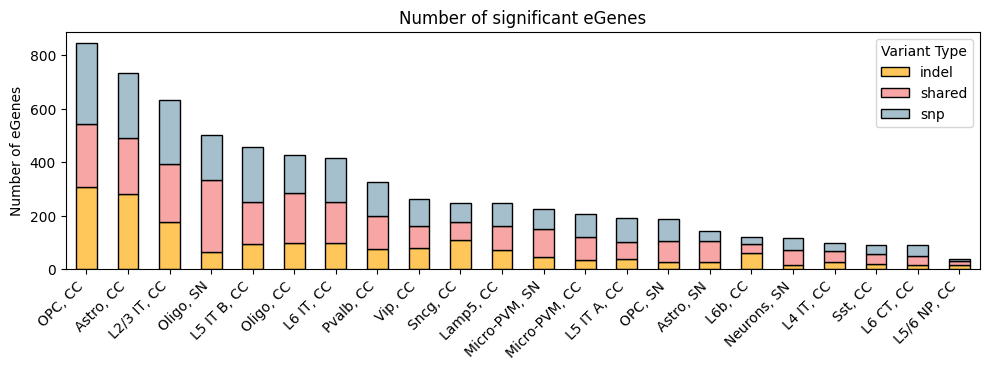

In [ ]:
# barplot with shared eGenes as separate category
shared_dict = {}
for cell_type, group in combined_cis_df.groupby('ct_reg'):
    sets = [set(group[group['variant_type'] == vt]['phenotype_id']) for vt in group['variant_type'].unique()]
    if len(sets) > 1:
        shared_dict[cell_type] = set.intersection(*sets)
    else:
        shared_dict[cell_type] = set()

grouped = (
    combined_cis_df
    .groupby(['ct_reg', 'variant_type'])['phenotype_id']
    .nunique()
    .reset_index(name='count')
)


shared_rows = []
for cell_type, shared_ids in shared_dict.items():
    shared_count = len(shared_ids)
    if shared_count > 0:
        shared_rows.append({'ct_reg': cell_type, 'variant_type': 'shared', 'count': shared_count})


for idx, row in grouped.iterrows():
    cell_type = row['ct_reg']
    variant_type = row['variant_type']
    shared_count = len(shared_dict[cell_type])
    if shared_count > 0:

        only_variant_count = (
            len(set(combined_cis_df[
                (combined_cis_df['ct_reg'] == cell_type) &
                (combined_cis_df['variant_type'] == variant_type)
            ]['phenotype_id']) - shared_dict[cell_type])
        )
        grouped.at[idx, 'count'] = only_variant_count


plot_df = pd.concat([grouped, pd.DataFrame(shared_rows)], ignore_index=True)
pivot_df = plot_df.pivot_table(index='ct_reg', columns='variant_type', values='count', fill_value=0)
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='total', ascending=False)
pivot_df = pivot_df.drop(columns='total')


custom_colors = {
    'snp': '#A5BFCC',
    'indel': '#ffc759',
    'shared': '#F7A5A5', 
}
colors = [custom_colors.get(col, '#333333') for col in pivot_df.columns]

pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 4),
    color=colors,
    edgecolor='black'
)
plt.ylabel('Number of eGenes')
plt.xlabel('')
plt.title('Number of significant eGenes')
plt.legend(title='Variant Type')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig('figures/manuscript_barplot_egenes.pdf', dpi=300, bbox_inches='tight')
plt.show()

## nr cells vs nr eGenes

In [ ]:
cc_nr = pd.read_csv('../../snRNA/01_analysis/04_QTL/cell_numbers/cc_number_of_cells.tsv', sep = '\t')
cc_nr = cc_nr.rename(columns={"consensus_cell_type_corrected": "cell_type"})
sn_nr = pd.read_csv('../../snRNA/01_analysis/04_QTL/cell_numbers/sn_number_of_cells.tsv', sep = '\t')
sn_nr = sn_nr.rename(columns={"cell_type_simplified": "cell_type"})
sn_nr['region'] = 'SN'
cc_nr['region'] = 'CC'

In [44]:
ct_nr = pd.concat([cc_nr,sn_nr])
ct_nr['cell_type'] = ct_nr['cell_type'].replace(cell_type_labels_corr)
ct_nr['ct_reg'] = ct_nr['cell_type'] + ', ' + ct_nr['region']
ct_nr

,cell_type,count,region,ct_reg
0,L2/3 IT,135968,CC,"L2/3 IT, CC"
1,Astro,122948,CC,"Astro, CC"
2,Oligo,116404,CC,"Oligo, CC"
3,OPC,59762,CC,"OPC, CC"
4,Micro-PVM,50220,CC,"Micro-PVM, CC"
5,Pvalb,35794,CC,"Pvalb, CC"
6,Vip,32849,CC,"Vip, CC"
7,L5 IT B,29848,CC,"L5 IT B, CC"
8,Sst,23378,CC,"Sst, CC"
9,Lamp5,23260,CC,"Lamp5, CC"


In [ ]:
df = combined_cis_df.groupby(by='ct_reg').phenotype_id.nunique()
df

In [45]:
grouped = ct_nr.join(df, on = 'ct_reg',how ='inner')
grouped

,cell_type,count,region,ct_reg,phenotype_id
0,L2/3 IT,135968,CC,"L2/3 IT, CC",634
1,Astro,122948,CC,"Astro, CC",733
2,Oligo,116404,CC,"Oligo, CC",426
3,OPC,59762,CC,"OPC, CC",845
4,Micro-PVM,50220,CC,"Micro-PVM, CC",206
5,Pvalb,35794,CC,"Pvalb, CC",326
6,Vip,32849,CC,"Vip, CC",264
7,L5 IT B,29848,CC,"L5 IT B, CC",456
8,Sst,23378,CC,"Sst, CC",92
9,Lamp5,23260,CC,"Lamp5, CC",247


In [ ]:
dict_colors =  {'L2/3 IT': '#ff0000',
                 'Oligo': '#149900',
 'Astro': '#8f00b3',
 'OPC': '#2EF0F0',
 'Micro-PVM': '#bf9360',
 'L5 IT': '#B2F7B7',
 'Vip': '#79baf2',
 'Pvalb': '#FA9A6E',
 'Sst': '#990000',
 'L6 IT': '#F7A400',
 'Lamp5': '#2d4459',
 'L4 IT': '#307cbf',
 'L6 CT': '#4c0000',
 'Sncg': '#FA7ADC',
 'L6b': '#00f220',
 'L5/6 NP': '#accbe6',
 'L5 ET': '#520066',
 'L6 IT Car3': '#330000',
 'VLMC': '#594f43',
 'Endo': '#16591f',
 'Sst Chodl': '#00FF00',
 'Neurons': '#999545',
 'DopaN': '#cc3333',
 'neuron_GLUL+': '#e59900',
 'GabaN': '#ace6b4',
 'OLG/OPC': '#262d33',
 'neuron_unk': '#ee00ff',
 'GlutaN': '#e57373',
 'unk': '#8c5e00',
'immune':'deepskyblue',
 'L5 IT B':'#B2F7B7',
'L5 IT A':'palegreen',
}

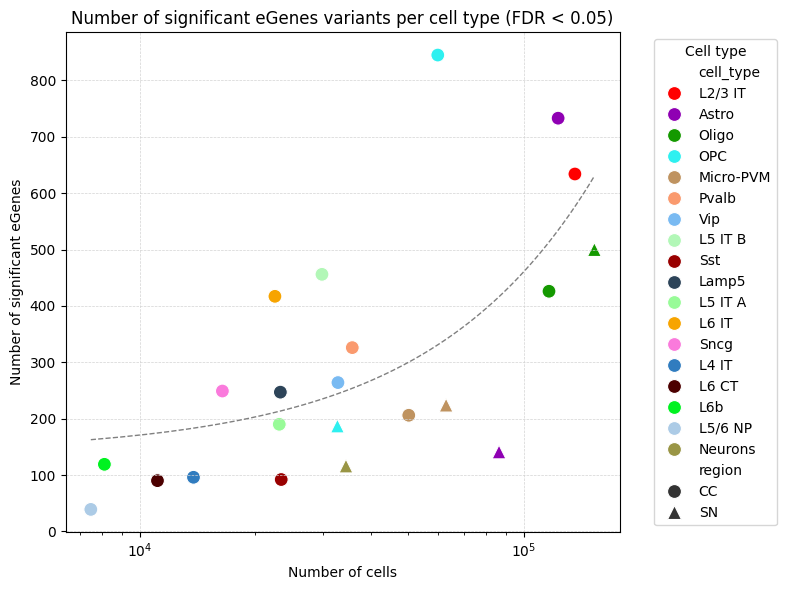

In [47]:
grouped['color'] = grouped['cell_type'].map(dict_colors)

plt.figure(figsize=(8, 6))
scatter_plot = sns.scatterplot(
    data=grouped,
    x='count',
    y='phenotype_id',
    hue='cell_type',  # Color by cell type
    style='region',   # Shape by region
    palette=dict_colors,  # Color palette
    s=100,
    markers={'CC': 'o', 'SN': '^'}
)


sns.regplot(
    data=grouped,
    x='count',
    y='phenotype_id',
    scatter=False,  
    color='grey',   # Line color
    line_kws={'linewidth': 1, 'linestyle': '--'},
    ci = None
)

plt.xscale('log')

# Add labels and title
plt.grid(color='lightgrey', linestyle='--', linewidth=0.5)
plt.xlabel('Number of cells')
plt.ylabel('Number of significant eGenes')
plt.title('Number of significant eGenes variants per cell type (FDR < 0.05)')
plt.legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
plt.tight_layout()

plt.savefig('figures/scatter_eGene_number_cells_log.pdf', format='pdf', dpi=300, bbox_inches='tight')# Show the plot

plt.show()